<a href="https://colab.research.google.com/github/DeepthiManthapuram/Deep_Learning/blob/main/Transformers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Smart Language Translation System using Transformer Architecture
Problem Statement
A multinational company operates customer support centers across multiple countries. Customer queries arrive in English, but support agents in France require the same queries in French.
Your task is to build a Transformer-based Neural Machine Translation (NMT) system that translates English sentences into French.
The implementation must demonstrate every major component of the Transformer architecture.

In [33]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dhruvildave/en-fr-translation-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'en-fr-translation-dataset' dataset.
Path to dataset files: /kaggle/input/en-fr-translation-dataset


In [34]:
import os

for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/en-fr-translation-dataset/en-fr.csv


In [35]:
import pandas as pd

chunks = []

for chunk in pd.read_csv(
        f"{path}/en-fr.csv",
        chunksize=10000):
    chunks.append(chunk)

    if len(chunks) == 5:  # 50k rows
        break

df = pd.concat(chunks)

print(df.shape)

(50000, 2)


# Task 1: Data Preparation
Objective
Prepare the English-French dataset for Transformer training.
Requirements
Load the dataset.
Convert text to lowercase.
Remove unnecessary symbols.
Add special tokens:
<start>
<end>
Example:
English:
The cat chased the mouse.
French:
<start> Le chat a poursuivi la souris. <end>
Create source and target vocabularies.
Convert words into integer tokens.

In [36]:
#Convert text to lowercase.
df['en'] = df['en'].str.lower()
df['fr'] = df['fr'].str.lower()

df.head(5)

,en,fr
0,changing lives | changing society | how it wor...,il a transformé notre vie | il a transformé la...
1,site map,plan du site
2,feedback,rétroaction
3,credits,crédits
4,français,english


In [37]:
#Remove unnecessary symbols.
df['en'] = df['en'].str.replace(r"[^\w\s']", "", regex=True)
df['fr'] = df['fr'].str.replace(r"[^\w\s']", "", regex=True)

In [38]:
#rename columns
df.rename(columns={
    'en': 'English',
    'fr': 'French'
},inplace=True)

In [39]:
#add special tokens
df['French'] = df['French'].apply(
    lambda x: '<start> ' + str(x) + ' <end>'
)

In [40]:
#Tokenizer
from tensorflow.keras.preprocessing.text import Tokenizer

english_tokenizer=Tokenizer(filters='')
english_tokenizer.fit_on_texts(df['English'].astype(str))
english_vocab_size=len(english_tokenizer.word_index)+1
print('English Vocabulary Size: ',english_vocab_size)

french_tokenizer=Tokenizer(filters='')
french_tokenizer.fit_on_texts(df['French'].astype(str))
french_vocab_size=len(french_tokenizer.word_index)+1
print('French Vocabulary Size: ',french_vocab_size)

English Vocabulary Size:  48920
French Vocabulary Size:  55176


In [41]:
#Convert Sentences to Integer Tokens

encoder_sequences=english_tokenizer.texts_to_sequences(df['English'].astype(str)) #English
decoder_sequences=french_tokenizer.texts_to_sequences(df['French'].astype(str)) #French

In [42]:
#Find Maximum Sequence Length

max_english_length=max([len(seq) for seq in encoder_sequences])
max_french_length=max([len(seq) for seq in decoder_sequences])

print('Maximum English Sequence Length: ',max_english_length)
print('Maximum French Sequence Length: ',max_french_length)

Maximum English Sequence Length:  707
Maximum French Sequence Length:  689


In [43]:
#Pad Sequences

from tensorflow.keras.preprocessing.sequence import pad_sequences

# Calculate max lengths after tokenization
max_english_length = 50
max_french_length = 50

encoder_sequences=pad_sequences(encoder_sequences, maxlen=max_english_length, padding='post')
decoder_sequences=pad_sequences(decoder_sequences,maxlen=max_french_length, padding='post')

print("Encoder Input Shape:",encoder_sequences.shape)
print("Decoder Input Shape:",decoder_sequences.shape)

Encoder Input Shape: (50000, 50)
Decoder Input Shape: (50000, 50)


# Task 2: Embedding Layer
Objective
Convert tokens into dense vectors.
Example:
The    → [0.12, 0.78, 0.43]
cat    → [0.81, 0.23, 0.55]
mouse  → [0.45, 0.61, 0.77]
Deliverables
Explain:
Why embeddings are required.  
Difference between One-Hot Encoding and Embeddings.

### Why Embeddings are Required

Embeddings are crucial in Natural Language Processing (NLP) because they allow words (or tokens) to be represented as dense, continuous vectors in a lower-dimensional space. This approach offers several advantages over traditional methods like one-hot encoding:

1.  **Capturing Semantic Relationships:** Embeddings learn to represent words that are semantically similar closer to each other in the vector space. For example, the embedding for "king" might be similar to "queen," and the vector difference between "king" and "man" could be similar to the difference between "queen" and "woman."
2.  **Dimensionality Reduction:** One-hot encoding creates a vector with a dimension equal to the vocabulary size (which can be tens of thousands or more), resulting in sparse, high-dimensional representations. Embeddings map these words to much smaller, dense vectors (e.g., 50-300 dimensions), significantly reducing computational complexity and memory usage.
3.  **Handling Sparsity:** One-hot vectors are mostly zeros, making them sparse. Neural networks struggle with high-dimensional sparse inputs. Dense embeddings provide richer information with fewer dimensions.
4.  **Improved Generalization:** By capturing relationships, embeddings allow models to generalize better to unseen words or contexts, as they can leverage the knowledge learned from similar words.

### Difference Between One-Hot Encoding and Embeddings

| Feature             | One-Hot Encoding                                      | Word Embeddings                                       |
| :------------------ | :---------------------------------------------------- | :---------------------------------------------------- |
| **Representation**  | Sparse vector with a single '1' and many '0's.        | Dense, continuous vector of real numbers.             |
| **Dimensionality**  | High (equal to vocabulary size).                      | Low (e.g., 50-300 dimensions), chosen as a hyperparameter. |
| **Information**     | Only indicates presence/absence of a word.            | Captures semantic and syntactic relationships.        |
| **Sparsity**        | Highly sparse.                                        | Dense.                                                |
| **Computational Cost** | High for large vocabularies due to high dimensionality. | Lower due to reduced dimensionality.                  |
| **Semantic Value**  | None; each word is equidistant from others.           | High; similar words are close in vector space.        |
| **Example (Vocab: [cat, dog, mouse])** | `cat = [1,0,0]`, `dog = [0,1,0]`                      | `cat = [0.1, 0.2, 0.3]`, `dog = [0.15, 0.25, 0.32]` |

In summary, while one-hot encoding is a simple way to represent categorical data, embeddings provide a much more powerful and efficient representation for words in NLP tasks, enabling models to understand the nuances of language.

In [44]:
from tensorflow.keras.layers import Embedding

embedding_dim = 32 # Using 32 as the embedding dimension to manage memory

# Creating encoder embedding
encoder_embedding = Embedding(
    input_dim=english_vocab_size,
    output_dim=embedding_dim
)

# Creating decoder embedding
decoder_embedding = Embedding(
    input_dim=french_vocab_size,
    output_dim=embedding_dim
)

In [45]:
import tensorflow as tf

encoder_sequences = tf.convert_to_tensor(encoder_sequences)
decoder_sequences = tf.convert_to_tensor(decoder_sequences)

#Convert tokens into dense vectors
encoder_embedded = encoder_embedding(encoder_sequences)
decoder_embedded = decoder_embedding(decoder_sequences)

print("Encoder Embedding Shape:", encoder_embedded.shape)
print("Decoder Embedding Shape:", decoder_embedded.shape)

Encoder Embedding Shape: (50000, 50, 32)
Decoder Embedding Shape: (50000, 50, 32)


# Task 4: Scaled Dot Product Attention
Objective
Implement Attention Mechanism.
Deliverables
Implement:
scaled_dot_product_attention(Q,K,V)
Show:
Attention Scores
Attention Weights
Context Vectors
For the sentence:
The cat chased the mouse

In [46]:
#Define Scaled Dot Product Attention

import tensorflow as tf
import numpy as np

def scaled_dot_product_attention(Q, K, V):

    # Q × Kᵀ
    matmul_qk = tf.matmul(Q, K, transpose_b=True)

    # Scale by √dk
    dk = tf.cast(tf.shape(K)[-1], tf.float32)
    scaled_scores = matmul_qk / tf.math.sqrt(dk)

    # Softmax
    attention_weights = tf.nn.softmax(scaled_scores, axis=-1)

    # Weighted sum
    context_vectors = tf.matmul(attention_weights, V)

    return scaled_scores, attention_weights, context_vectors

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Define the input sentence
sentence = "the cat chased the mouse"

# Tokenize the sentence
sentence_tokens = english_tokenizer.texts_to_sequences([sentence])

# Get original words for visualization labels (excluding padding)
words_in_sentence = [english_tokenizer.index_word[token] for token in sentence_tokens[0]]

# Pad the tokenized sequence
sentence_padded = pad_sequences(sentence_tokens, maxlen=max_english_length, padding='post')

# Convert to tensor and get embeddings
sentence_embedded = encoder_embedding(tf.convert_to_tensor(sentence_padded))

# For self-attention, Q, K, and V are typically derived from the same input
Q_example = sentence_embedded
K_example = sentence_embedded
V_example = sentence_embedded

print(f"Original sentence: '{sentence}'")
print(f"Tokenized sequence: {sentence_tokens[0]}")
print(f"Padded sequence shape: {sentence_padded.shape}")
print(f"Embedded sequence shape (Q, K, V shape): {sentence_embedded.shape}")

Original sentence: 'the cat chased the mouse'
Tokenized sequence: [1, 2369, 1, 9488]
Padded sequence shape: (1, 50)
Embedded sequence shape (Q, K, V shape): (1, 50, 32)


In [48]:
# Apply scaled dot product attention
scaled_scores, attention_weights, context_vectors = scaled_dot_product_attention(Q_example, K_example, V_example)

print("\n--- Attention Scores (first 5x5 for brevity) ---")
print(scaled_scores[0, :len(words_in_sentence), :len(words_in_sentence)].numpy())

print("\n--- Attention Weights (first 5x5 for brevity) ---")
print(attention_weights[0, :len(words_in_sentence), :len(words_in_sentence)].numpy())

print("\n--- Context Vectors (first 5 words) ---")
print(context_vectors[0, :len(words_in_sentence), :].numpy())


--- Attention Scores (first 5x5 for brevity) ---
[[ 0.00414788 -0.00031088  0.00414788 -0.00121033]
 [-0.00031088  0.00410376 -0.00031088  0.00019821]
 [ 0.00414788 -0.00031088  0.00414788 -0.00121033]
 [-0.00121033  0.00019821 -0.00121033  0.00491453]]

--- Attention Weights (first 5x5 for brevity) ---
[[0.0200712  0.01998191 0.0200712  0.01996394]
 [0.01999702 0.0200855  0.01999702 0.02000721]
 [0.0200712  0.01998191 0.0200712  0.01996394]
 [0.019987   0.02001517 0.019987   0.02010979]]

--- Context Vectors (first 5 words) ---
[[-0.00656108  0.02557237 -0.02015863 -0.01823164  0.03535082 -0.04509316
   0.04452817 -0.00505607  0.0149798  -0.01775078  0.00296662 -0.03164653
  -0.04641047 -0.01165721 -0.04075015  0.01853686  0.0176366  -0.01154255
   0.00187859 -0.01066488  0.00522522  0.01518414  0.02528113 -0.02652126
   0.01360198 -0.04048418  0.00780242 -0.01193973  0.01760592  0.03019931
   0.03644527 -0.03430572]
 [-0.0065621   0.02556932 -0.02016469 -0.01822864  0.03533842 -0.04

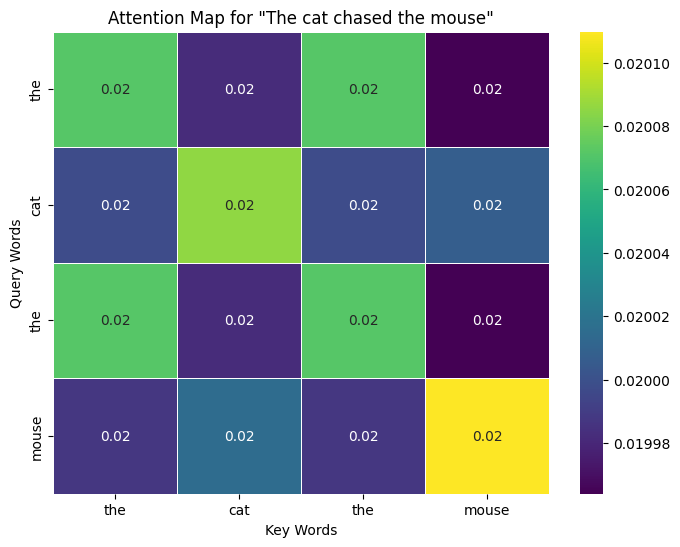

In [49]:
# Extract attention weights for the actual words (remove padding dimensions)
# The attention_weights shape is (batch_size, sequence_length, sequence_length)
attention_weights_actual = attention_weights[0, :len(words_in_sentence), :len(words_in_sentence)]

plt.figure(figsize=(8, 6))
sns.heatmap(
    attention_weights_actual,
    xticklabels=words_in_sentence,
    yticklabels=words_in_sentence,
    cmap='viridis',
    annot=True, # Show the attention values on the heatmap
    fmt=".2f", # Format annotation to two decimal places
    linewidths=.5 # Add lines between cells
)
plt.title('Attention Map for "The cat chased the mouse"')
plt.xlabel('Key Words')
plt.ylabel('Query Words')
plt.show()

# Task 5: Multi-Head Attention
Objective
Implement Multi-Head Attention.
Deliverables
Use at least:
4 Attention Heads
Analyze:
Head 1 → Subject-Verb Relationships
Head 2 → Verb-Object Relationships
Head 3 → Long-Term Dependencies
Head 4 → Semantic Context

In [50]:
import tensorflow as tf
from tensorflow.keras.layers import MultiHeadAttention

In [51]:
sentence = "the cat chased the mouse"

sequence = english_tokenizer.texts_to_sequences([sentence])
sequence = tf.convert_to_tensor(sequence)

In [52]:
embedding_dim = 32

embedding_layer = tf.keras.layers.Embedding(
    input_dim=english_vocab_size,
    output_dim=embedding_dim
)

embedded_sentence = embedding_layer(sequence)

print(embedded_sentence.shape)

(1, 4, 32)


In [53]:
#Create Multi-Head Attention Layer
multi_head_attention = MultiHeadAttention(
    num_heads=4,
    key_dim=8
)

In [54]:
#Apply Multi-Head Attention
attention_output, attention_scores = multi_head_attention(
    query=embedded_sentence,
    value=embedded_sentence,
    key=embedded_sentence,
    return_attention_scores=True
)

In [55]:
print("Attention Output Shape:", attention_output.shape)
print("Attention Scores Shape:", attention_scores.shape)

Attention Output Shape: (1, 4, 32)
Attention Scores Shape: (1, 4, 4, 4)


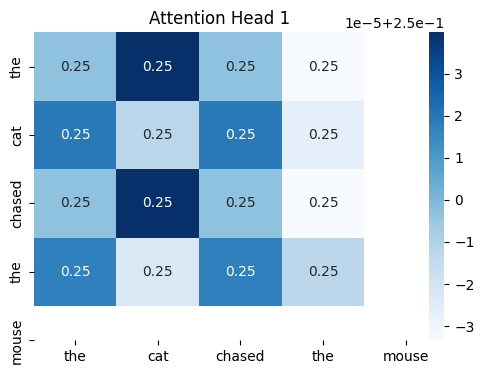

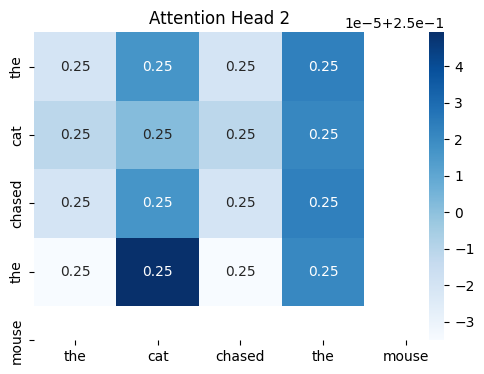

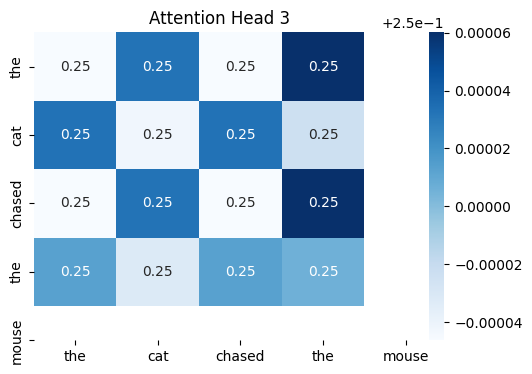

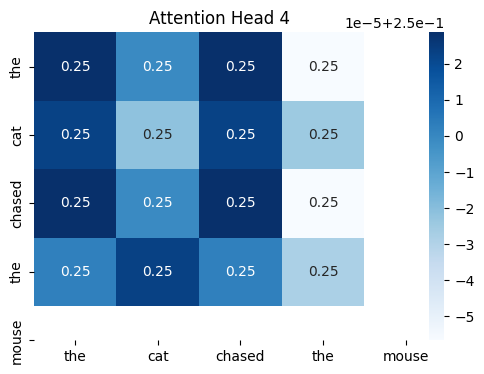

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

words = ["the", "cat", "chased", "the", "mouse"]

for head in range(4):

    plt.figure(figsize=(6,4))

    sns.heatmap(
        attention_scores[0, head].numpy(),
        annot=True,
        xticklabels=words,
        yticklabels=words,
        cmap="Blues"
    )

    plt.title(f"Attention Head {head+1}")
    plt.show()

# Task 6: Encoder Construction
Objective
Build the Transformer Encoder.
Architecture
Input
 ↓
Embedding
 ↓
Positional Encoding
 ↓
Multi-Head Attention
 ↓
Add & Norm
 ↓
Feed Forward Network
 ↓
Add & Norm
 ↓
Encoder Output
Deliverables
Implement Encoder Layer from scratch.

In [57]:
import tensorflow as tf
from tensorflow.keras.layers import Layer, Dense, Dropout, LayerNormalization
import numpy as np

class PositionalEncoding(Layer):
    def __init__(self, position, d_model, **kwargs):
        super(PositionalEncoding, self).__init__(**kwargs)
        self.pos_encoding = self.positional_encoding(position, d_model)

    def get_angles(self, position, i, d_model):
        angles = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        return position * angles

    def positional_encoding(self, position, d_model):
        angle_rads = self.get_angles(np.arange(position)[:, np.newaxis],
                                     np.arange(d_model)[np.newaxis, :],
                                     d_model)

        # apply sin to even indices in the array; 2i
        angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])

        # apply cos to odd indices in the array; 2i + 1
        angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])

        pos_encoding = angle_rads[np.newaxis, ...]
        return tf.cast(pos_encoding, dtype=tf.float32)

    def call(self, inputs):
        return inputs + self.pos_encoding[:, :tf.shape(inputs)[1], :]

    def get_config(self):
        config = super(PositionalEncoding, self).get_config()
        config.update({
            "position": self.pos_encoding.shape[1],
            "d_model": self.pos_encoding.shape[2]
        })
        return config

# Example usage (not executed, for demonstration of the layer)
# max_seq_len = 50
# d_model_dim = 32 # embedding_dim
# pos_encoder = PositionalEncoding(max_seq_len, d_model_dim)
# sample_input = tf.random.uniform((1, max_seq_len, d_model_dim))
# output = pos_encoder(sample_input)
# print(output.shape)


### Feed Forward Network

This network consists of two linear transformations with a ReLU activation in between. It's applied independently to each position.

In [58]:
def feed_forward_network(d_model, dff):
    return tf.keras.Sequential([
        Dense(dff, activation='relu'),  # (batch_size, seq_len, dff)
        Dense(d_model)                 # (batch_size, seq_len, d_model)
    ])

# Example usage
# d_model_dim = 32
# dff_dim = 128
# ffn = feed_forward_network(d_model_dim, dff_dim)
# sample_input = tf.random.uniform((1, 50, d_model_dim))
# output = ffn(sample_input)
# print(output.shape)


### Encoder Layer

Each encoder layer consists of two sub-layers: a Multi-Head Attention mechanism and a Position-wise Feed Forward Network. Both sub-layers employ a residual connection followed by layer normalization.

In [59]:
class EncoderLayer(Layer):
    def __init__(self, d_model, num_heads, dff, rate=0.1, **kwargs):
        super(EncoderLayer, self).__init__(**kwargs)

        self.mha = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model // num_heads)
        self.ffn = feed_forward_network(d_model, dff)

        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)

        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def call(self, x, training, mask=None):
        # Multi-Head Attention Block
        attn_output = self.mha(query=x, value=x, key=x, attention_mask=mask)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(x + attn_output)  # Add & Norm

        # Feed Forward Network Block
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        out2 = self.layernorm2(out1 + ffn_output)  # Add & Norm

        return out2

    def get_config(self):
        config = super(EncoderLayer, self).get_config()
        config.update({
            "d_model": self.mha.key_dim * self.mha.num_heads,
            "num_heads": self.mha.num_heads,
            "dff": self.ffn.layers[0].units, # Assuming first layer is Dense and has units attribute
            "rate": self.dropout1.rate
        })
        return config


### Encoder

The Encoder consists of an input embedding, positional encoding, and a stack of `EncoderLayer` instances.

In [61]:
class Encoder(Layer):
    def __init__(self, num_layers, d_model, num_heads, dff, input_vocab_size, maximum_position_encoding, rate=0.1, **kwargs):
        super(Encoder, self).__init__(**kwargs)

        self.d_model = d_model
        self.num_layers = num_layers

        self.embedding = Embedding(input_vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(maximum_position_encoding, self.d_model)

        self.enc_layers = [EncoderLayer(d_model, num_heads, dff, rate) for _ in range(num_layers)]

        self.dropout = Dropout(rate)

    def call(self, x, training, mask=None):
        seq_len = tf.shape(x)[1]

        # Add embedding and positional encoding.
        x = self.embedding(x)  # (batch_size, input_seq_len, d_model)
        x *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))
        x = self.pos_encoding(x)

        x = self.dropout(x, training=training)

        for i in range(self.num_layers):
            x = self.enc_layers[i](x, training, mask) # mask is passed to MultiHeadAttention inside EncoderLayer

        return x  # (batch_size, input_seq_len, d_model)

    def get_config(self):
        config = super(Encoder, self).get_config()
        config.update({
            "num_layers": self.num_layers,
            "d_model": self.d_model,
            "num_heads": self.enc_layers[0].mha.num_heads, # Assuming all layers have the same num_heads
            "dff": self.enc_layers[0].ffn.layers[0].units,
            "input_vocab_size": self.embedding.input_dim,
            "maximum_position_encoding": self.pos_encoding.pos_encoding.shape[1],
            "rate": self.dropout.rate
        })
        return config


# Task 7: Decoder Construction
Objective
Build the Transformer Decoder.
Architecture
Previous French Words
 ↓
Masked Multi-Head Attention
 ↓
Encoder-Decoder Attention
 ↓
Feed Forward Network
 ↓
Output Probabilities
Deliverables
Implement:
Masked Attention
Cross Attention
Decoder Layer


### Masked Multi-Head Attention

Masked attention is crucial in the decoder to prevent it from attending to future tokens during training. This ensures that the prediction for a token depends only on the preceding tokens.

In [67]:
import tensorflow as tf
from tensorflow.keras.layers import Layer, Dense, Dropout, LayerNormalization, Embedding
import numpy as np

def create_padding_mask(seq):
    seq = tf.cast(tf.math.equal(seq, 0), tf.float32)
    # Add extra dimensions to add the padding
    # to the attention logits. For example, batch_size, 1, 1, seq_len
    return seq[:, tf.newaxis, tf.newaxis, :]

def create_look_ahead_mask(size):
    mask = 1 - tf.linalg.band_part(tf.ones((size, size)), -1, 0)
    return mask  # (seq_len, seq_len)

# Example usage of masks (not executed, for demonstration)
# x = tf.constant([[7, 6, 0, 0, 1], [1, 2, 3, 0, 0]]) # Example sequence with padding (0s)
# padding_mask = create_padding_mask(x)
# print("Padding Mask shape:", padding_mask.shape)
# print("Padding Mask:\n", padding_mask)

# look_ahead_mask = create_look_ahead_mask(5)
# print("Look-ahead Mask shape:", look_ahead_mask.shape)
# print("Look-ahead Mask:\n", look_ahead_mask)

### Decoder Layer

Each decoder layer consists of three sub-layers:

1.  **Masked Multi-Head Attention (Self-Attention):** The decoder's self-attention layer. It attends to all positions up to and including the current position in the target sequence.
2.  **Multi-Head Attention (Encoder-Decoder Attention):** This layer attends to the output of the encoder. This is where the encoder and decoder communicate.
3.  **Position-wise Feed Forward Network:** Identical to the one in the encoder.

In [68]:
class DecoderLayer(Layer):
    def __init__(self, d_model, num_heads, dff, rate=0.1, **kwargs):
        super(DecoderLayer, self).__init__(**kwargs)

        self.mha1 = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model // num_heads)
        self.mha2 = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model // num_heads)

        self.ffn = feed_forward_network(d_model, dff) # Assumes feed_forward_network is defined earlier

        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.layernorm3 = LayerNormalization(epsilon=1e-6)

        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)
        self.dropout3 = Dropout(rate)

    def call(self, x, enc_output, training, look_ahead_mask, padding_mask):
        # Masked Multi-Head Attention (Self-Attention)
        attn1, attn_weights_block1 = self.mha1(query=x, value=x, key=x, attention_mask=look_ahead_mask, return_attention_scores=True)
        attn1 = self.dropout1(attn1, training=training)
        out1 = self.layernorm1(attn1 + x)

        # Multi-Head Attention (Encoder-Decoder Attention / Cross-Attention)
        attn2, attn_weights_block2 = self.mha2(query=out1, value=enc_output, key=enc_output, attention_mask=padding_mask, return_attention_scores=True)
        attn2 = self.dropout2(attn2, training=training)
        out2 = self.layernorm2(attn2 + out1)

        # Feed Forward Network
        ffn_output = self.ffn(out2)
        ffn_output = self.dropout3(ffn_output, training=training)
        out3 = self.layernorm3(ffn_output + out2)

        return out3, attn_weights_block1, attn_weights_block2

    def get_config(self):
        config = super(DecoderLayer, self).get_config()
        config.update({
            "d_model": self.mha1.key_dim * self.mha1.num_heads,
            "num_heads": self.mha1.num_heads,
            "dff": self.ffn.layers[0].units, # Assuming first layer is Dense and has units attribute
            "rate": self.dropout1.rate
        })
        return config

### Decoder

The Decoder comprises an input embedding layer, positional encoding, and a stack of `DecoderLayer` instances. It takes the target sequence and the encoder's output as input to generate the final output.

In [69]:
class Decoder(Layer):
    def __init__(self, num_layers, d_model, num_heads, dff, target_vocab_size, maximum_position_encoding, rate=0.1, **kwargs):
        super(Decoder, self).__init__(**kwargs)

        self.d_model = d_model
        self.num_layers = num_layers

        self.embedding = Embedding(target_vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(maximum_position_encoding, self.d_model) # Assumes PositionalEncoding is defined earlier

        self.dec_layers = [DecoderLayer(d_model, num_heads, dff, rate) for _ in range(num_layers)]
        self.dropout = Dropout(rate)

    def call(self, x, enc_output, training, look_ahead_mask, padding_mask):
        seq_len = tf.shape(x)[1]
        attention_weights = {}

        x = self.embedding(x)  # (batch_size, target_seq_len, d_model)
        x *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))
        x = self.pos_encoding(x)

        x = self.dropout(x, training=training)

        for i in range(self.num_layers):
            x, block1, block2 = self.dec_layers[i](x, enc_output, training, look_ahead_mask, padding_mask)

            attention_weights[f'decoder_layer{i+1}_block1'] = block1
            attention_weights[f'decoder_layer{i+1}_block2'] = block2

        # x.shape == (batch_size, target_seq_len, d_model)
        return x, attention_weights

    def get_config(self):
        config = super(Decoder, self).get_config()
        config.update({
            "num_layers": self.num_layers,
            "d_model": self.d_model,
            "num_heads": self.dec_layers[0].mha1.num_heads, # Assuming all layers have the same num_heads
            "dff": self.dec_layers[0].ffn.layers[0].units,
            "target_vocab_size": self.embedding.input_dim,
            "maximum_position_encoding": self.pos_encoding.pos_encoding.shape[1],
            "rate": self.dropout.rate
        })
        return config

## Task 8: Full Transformer Model

### Objective
Combine the Encoder and Decoder to build the complete Transformer architecture.

### Architecture
English Sentence
 ↓
Encoder
 ↓
Context Representation
 ↓
Decoder
 ↓
French Sentence

### Deliverables
Implement the complete Transformer model.

### Transformer Model

This class combines the Encoder and Decoder. It takes the English input and French target sequence, processes them through their respective components, and outputs the predicted French token probabilities.

In [70]:
class Transformer(Layer):
    def __init__(self, num_layers, d_model, num_heads, dff, input_vocab_size,
                 target_vocab_size, pe_input, pe_target, rate=0.1, **kwargs):
        super(Transformer, self).__init__(**kwargs)

        self.encoder = Encoder(num_layers, d_model, num_heads, dff,
                               input_vocab_size, pe_input, rate)

        self.decoder = Decoder(num_layers, d_model, num_heads, dff,
                               target_vocab_size, pe_target, rate)

        self.final_layer = Dense(target_vocab_size)

    def call(self, inp, tar, training, enc_padding_mask, look_ahead_mask, dec_padding_mask):
        enc_output = self.encoder(inp, training, enc_padding_mask)  # (batch_size, inp_seq_len, d_model)

        # dec_output.shape == (batch_size, tar_seq_len, d_model)
        dec_output, attention_weights = self.decoder(
            tar, enc_output, training, look_ahead_mask, dec_padding_mask)

        final_output = self.final_layer(dec_output)  # (batch_size, tar_seq_len, target_vocab_size)

        return final_output, attention_weights

    def get_config(self):
        config = super(Transformer, self).get_config()
        config.update({
            "num_layers": self.encoder.num_layers,
            "d_model": self.encoder.d_model,
            "num_heads": self.encoder.enc_layers[0].mha.num_heads,
            "dff": self.encoder.enc_layers[0].ffn.layers[0].units,
            "input_vocab_size": self.encoder.embedding.input_dim,
            "target_vocab_size": self.decoder.embedding.input_dim,
            "pe_input": self.encoder.pos_encoding.pos_encoding.shape[1],
            "pe_target": self.decoder.pos_encoding.pos_encoding.shape[1],
            "rate": self.encoder.dropout.rate # Assuming same dropout rate for both encoder and decoder
        })
        return config

### Define Model Hyperparameters

In [71]:
# Hyperparameters for the Transformer model
NUM_LAYERS = 2
D_MODEL = embedding_dim # Use the previously defined embedding_dim
NUM_HEADS = 4
DFF = 128  # Dimension of the feed-forward network
DROPOUT_RATE = 0.1

# Input and target vocabulary sizes from data preparation
INPUT_VOCAB_SIZE = english_vocab_size
TARGET_VOCAB_SIZE = french_vocab_size

# Positional encoding maximum lengths from data preparation
PE_INPUT = max_english_length
PE_TARGET = max_french_length

print(f"Number of Layers: {NUM_LAYERS}")
print(f"Model Dimension (d_model): {D_MODEL}")
print(f"Number of Attention Heads: {NUM_HEADS}")
print(f"Feed Forward Dimension (dff): {DFF}")
print(f"Dropout Rate: {DROPOUT_RATE}")
print(f"English Vocabulary Size: {INPUT_VOCAB_SIZE}")
print(f"French Vocabulary Size: {TARGET_VOCAB_SIZE}")
print(f"Max English Sequence Length (for Positional Encoding): {PE_INPUT}")
print(f"Max French Sequence Length (for Positional Encoding): {PE_TARGET}")

Number of Layers: 2
Model Dimension (d_model): 32
Number of Attention Heads: 4
Feed Forward Dimension (dff): 128
Dropout Rate: 0.1
English Vocabulary Size: 48920
French Vocabulary Size: 55176
Max English Sequence Length (for Positional Encoding): 50
Max French Sequence Length (for Positional Encoding): 50


### Instantiate the Transformer Model

In [72]:
transformer = Transformer(
    num_layers=NUM_LAYERS,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    dff=DFF,
    input_vocab_size=INPUT_VOCAB_SIZE,
    target_vocab_size=TARGET_VOCAB_SIZE,
    pe_input=PE_INPUT,
    pe_target=PE_TARGET,
    rate=DROPOUT_RATE
)

print("Transformer model instantiated.")
# You can print a summary if the model was built (i.e., called with input once)
# tf.keras.utils.plot_model(transformer, to_file='transformer_model.png', show_shapes=True)

Transformer model instantiated.


# Task 9: Translation Generation
Objective
Generate translations token-by-token.
Example:
Input:
The cat chased the mouse
Generation:
<start>
 ↓
Le
 ↓
Le chat
 ↓
Le chat a
 ↓
Le chat a poursuivi
 ↓
Le chat a poursuivi la
 ↓
Le chat a poursuivi la souris
 ↓
<end>
Explain how Masked Multi-Head Attention prevents the decoder from seeing future words.

In [77]:
def translate(input_sentence):
    # 1. Preprocess the input English sentence
    input_seq = english_tokenizer.texts_to_sequences([input_sentence])
    input_seq = tf.keras.preprocessing.sequence.pad_sequences(
        input_seq, maxlen=PE_INPUT, padding='post'
    )
    input_seq = tf.cast(input_seq, dtype=tf.int64)

    # 2. Create the encoder padding mask
    enc_padding_mask = create_padding_mask(input_seq)

    # 3. Initialize the decoder input with the <start> token
    start_token = french_tokenizer.word_index['<start>']
    end_token = french_tokenizer.word_index['<end>']

    # The decoder input will grow over time
    output_sequence = tf.expand_dims([start_token], 0) # (1, 1)

    # 4. Generate translation token by token
    for i in range(PE_TARGET): # Iterate up to max French length
        # Create the look-ahead mask for decoder self-attention
        look_ahead_mask = create_look_ahead_mask(tf.shape(output_sequence)[1])

        # Create the decoder padding mask (for cross-attention to encoder output)
        # Note: In a real scenario, this mask would be based on the encoder input sequence
        # which was already handled by enc_padding_mask. Here, it is the same for simplicity.
        dec_padding_mask = create_padding_mask(input_seq)

        predictions, attention_weights = transformer(
            inp=input_seq,
            tar=output_sequence,
            training=False, # Set training to False for inference
            enc_padding_mask=enc_padding_mask,
            look_ahead_mask=look_ahead_mask,
            dec_padding_mask=dec_padding_mask
        )

        # Select the last token from the sequence (the current prediction)
        predictions = predictions[:, -1:, :]
        predicted_id = tf.argmax(predictions, axis=-1)

        # Append the predicted token to the output sequence
        output_sequence = tf.concat([output_sequence, predicted_id], axis=-1)

        # Stop if the <end> token is predicted
        if predicted_id == end_token:
            break

    # Convert token IDs back to words
    output_words = []
    for token_id in output_sequence.numpy().flatten():
        if token_id != start_token and token_id != end_token and token_id != 0: # Exclude start, end, and padding
            output_words.append(french_tokenizer.index_word.get(token_id, ''))

    return ' '.join(output_words)

# Example usage (will not run without trained weights)
# print("\n--- Example Translation (requires trained model) ---")
# sample_english_sentence = "The cat chased the mouse"
# translated_french_sentence = translate(sample_english_sentence)
# print(f"English: {sample_english_sentence}")
# print(f"French: {translated_french_sentence}")

# Task 10: Evaluation
Evaluate using:
BLEU Score
Measure translation quality.
Example:
Actual:
Le chat a poursuivi la souris
Predicted:
Le chat a poursuivi la souris
BLEU Score = High


In [82]:
import nltk
from nltk.translate.bleu_score import sentence_bleu
from nltk.translate.bleu_score import SmoothingFunction

# Ensure NLTK data is available
try:
    nltk.data.find('tokenizers/punkt')
    nltk.data.find('tokenizers/punkt_tab') # Check for punkt_tab as well
except LookupError:
    nltk.download('punkt')
    nltk.download('punkt_tab') # Download punkt_tab if not found

# Use a smoothing function to avoid zero BLEU scores for short sentences or missing n-grams
# This is often needed, especially when dealing with single sentences
smoothie = SmoothingFunction().method4

def calculate_bleu_score(reference_sentence, hypothesis_sentence):
    # Tokenize the sentences
    reference_tokens = [nltk.word_tokenize(reference_sentence.lower())]
    hypothesis_tokens = nltk.word_tokenize(hypothesis_sentence.lower())

    # Calculate BLEU score
    # weights=(1,0,0,0) for unigram only, (0.5,0.5,0,0) for bigram only, etc.
    # Common practice is to use (0.25, 0.25, 0.25, 0.25) for 1-gram to 4-gram
    score = sentence_bleu(reference_tokens, hypothesis_tokens, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothie)
    return score

# --- Example Usage (with placeholder sentences since the model is not trained yet) ---
print("\n--- BLEU Score Calculation Example ---")

# Reference: Human-translated sentence
reference_1 = "Le chat a poursuivi la souris"
reference_2 = "Le chat a chassé la souris"

# Hypothesis: Machine-generated translation
hypothesis_perfect = "Le chat a poursuivi la souris"
hypothesis_good = "Le chat a poursuivi le rongeur"
hypothesis_bad = "Le chien a couru le ballon"

print(f"Reference 1: {reference_1}")
print(f"Reference 2: {reference_2}")

# BLEU for a perfect match
bleu_perfect = calculate_bleu_score(reference_1, hypothesis_perfect)
print(f"Hypothesis (perfect): '{hypothesis_perfect}' -> BLEU: {bleu_perfect:.4f}")

# BLEU for a good match (some variation)
bleu_good = calculate_bleu_score(reference_1, hypothesis_good)
print(f"Hypothesis (good): '{hypothesis_good}' -> BLEU: {bleu_good:.4f}")

# BLEU for a poor match
bleu_bad = calculate_bleu_score(reference_1, hypothesis_bad)
print(f"Hypothesis (bad): '{hypothesis_bad}' -> BLEU: {bleu_bad:.4f}")

# Note: For multiple references, you would provide a list of reference token lists
# Example with multiple references for the 'good' hypothesis:
multi_references = [
    nltk.word_tokenize(reference_1.lower()),
    nltk.word_tokenize(reference_2.lower())
]
hypothesis_tokens_good = nltk.word_tokenize(hypothesis_good.lower())
bleu_multi_ref = sentence_bleu(multi_references, hypothesis_tokens_good, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothie)
print(f"Hypothesis (good) with multiple references: '{hypothesis_good}' -> BLEU: {bleu_multi_ref:.4f}")


--- BLEU Score Calculation Example ---
Reference 1: Le chat a poursuivi la souris
Reference 2: Le chat a chassé la souris
Hypothesis (perfect): 'Le chat a poursuivi la souris' -> BLEU: 1.0000
Hypothesis (good): 'Le chat a poursuivi le rongeur' -> BLEU: 0.5081
Hypothesis (bad): 'Le chien a couru le ballon' -> BLEU: 0.0447
Hypothesis (good) with multiple references: 'Le chat a poursuivi le rongeur' -> BLEU: 0.5081
